In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [2]:
# Grab the data and do a rapid cleanup
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()

In [3]:
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth=3: Stops the tree at 3 levels deep. If you don't use this, the tree grows until every leaf is pure, creating an unreadable, overfitted massive web.
# random_state=42: Locks the math so you get the exact same tree every time you run it.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['sex'], 
    )], 
    remainder='passthrough'
                               )
# 1. The Overfitted Model (No limits)
unpruned_tree = Pipeline(steps=[
    ('transformer', transformer), 
    ('decision-tree', DecisionTreeClassifier())
])
unpruned_tree.fit(X_train, y_train)
unpruned_pred = unpruned_tree.predict(X_test)
# 2. The Pruned Model (max_depth=3)
pruned_tree = Pipeline(steps=[
    ('transformer', transformer), 
    ('decision-tree', DecisionTreeClassifier(max_depth=3, random_state=42))
])
        
pruned_tree.fit(X_train, y_train)
pruned_pred = pruned_tree.predict(X_test)

In [12]:
print("--- UNPRUNED TREE (No Limits) ---")
unpruned_train = unpruned_tree.score(X_train, y_train)
unpruned_test = unpruned_tree.score(X_test, y_test)
print(f"Training Accuracy: {unpruned_train:.3f}")
print(f"Testing Accuracy:  {unpruned_test:.3f}")
print(f"The Gap (Overfit): {(unpruned_train - unpruned_test):.3f}\n")

--- UNPRUNED TREE (No Limits) ---
Training Accuracy: 0.991
Testing Accuracy:  0.720
The Gap (Overfit): 0.271



In [13]:
print("--- PRUNED TREE (max_depth=3) ---")
pruned_train = pruned_tree.score(X_train, y_train)
pruned_test = pruned_tree.score(X_test, y_test)
print(f"Training Accuracy: {pruned_train:.3f}")
print(f"Testing Accuracy:  {pruned_test:.3f}")
print(f"The Gap (Overfit): {(pruned_train - pruned_test):.3f}")

--- PRUNED TREE (max_depth=3) ---
Training Accuracy: 0.827
Testing Accuracy:  0.741
The Gap (Overfit): 0.085


In [18]:
# 1. Extract the trained tree from your pruned pipeline
extracted_tree = pruned_tree[-1]

# 2. Extract the raw importance scores (a list of decimal numbers)
importances = extracted_tree.feature_importances_

# 3. Reconstruct the column names in the exact order the ColumnTransformer output them
# 'sex' went through the encoder first, the rest passed through after
feature_names = ['sex', 'pclass', 'age', 'fare']

In [19]:
# NEW: Sort the values so the biggest bar is at the top, then plot
# kind='barh' creates a horizontal bar chart
importance_series = pd.Series(importances, index=feature_names)

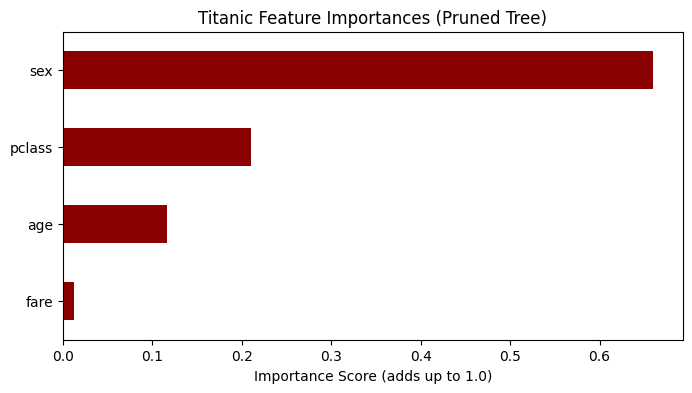

In [25]:
importance_series.sort_values().plot(kind='barh', color='darkred', figsize=(8, 4))


plt.title("Titanic Feature Importances (Pruned Tree)")
plt.xlabel("Importance Score (adds up to 1.0)")
plt.show()